# RealLift — GeoExperiment Quickstart

This notebook walks through the full geo-experiment pipeline using **synthetic data** — no prior dataset required.

**Pipeline:**
1. Generate synthetic geo data
2. Initialize `GeoExperiment`
3. Design of Experiments (DoE) — select treatment/control clusters, estimate MDE
4. Backtest — validate the design before any real campaign spend

In [1]:
from reallift import RealLift

## Step 1 — Generate Data

Creates a synthetic panel of daily geo-level metrics.
Each geo gets a random mean volume drawn log-uniformly from `mean_values`,
so the dataset mimics real markets where cities have very different sizes.

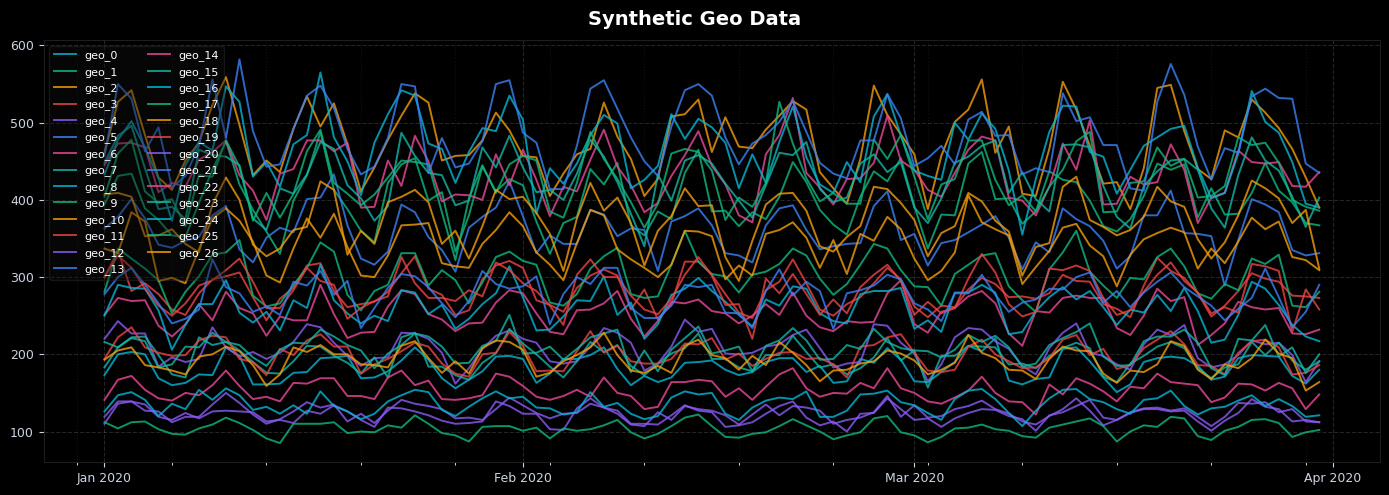

In [2]:
df = RealLift.GeoExperiment.generate_data(
    start_date="2020-01-01",
    end_date="2020-03-31",
    n_geos=27,
    mean_values=[100, 500],
    seasonality_amplitudes=0.10,
    seasonality_period=7,
    noise_std=0.05,
    random_seed=42,
    as_integer=True,
    plot=True,
)

## Step 2 — Initialize

`GeoExperiment` loads the data, parses dates, and detects geo columns.
Use `start_date` / `end_date` to window the analysis period.

In [3]:
rl = RealLift.GeoExperiment(
    data=df,
    date_col="date",
    start_date="2020-01-01",
    end_date="2020-03-31",
)


  RealLift initialized
  --------------------------------------------------
  Date column : date
  Date range  : 2020-01-01 -> 2020-03-31
  Rows        : 91
  Geos        : 27
  Window      : 2020-01-01 -> 2020-03-31
  --------------------------------------------------



In [5]:
doe = rl.design(
    pct_treatment=4/27,
    experiment_days=[21, 28, 35],
)


======================= DESIGN OF EXPERIMENTS ========================

Total geos available: 27
Scenarios to evaluate: 1
Pre-treatment period: 2020-01-01 → 2020-03-31
Experiment duration: [21, 28, 35]

  [Info] OOS Backtest will validate Ghost Lifts across ALL requested horizons at the end of the historical series.


  Evaluating full historical data for global ranking...
  Global ranking (top 4): ['geo_3', 'geo_9', 'geo_20', 'geo_10']

----------------------------------------------------------------------
SCENARIO 1 — 15% Treatment (4 geos)
----------------------------------------------------------------------

  [Greedy Lock Search]

    Iter 1 | Testing 4 candidates
      [GhostLift] geo_3      R²=0.7390  Gap=0.0465
      [Approved] geo_9      R²=0.6496  Gap=0.1787
      [GhostLift] geo_20     R²=0.6989  Gap=-0.0935
      [Approved] geo_10     R²=0.7210  Gap=0.0468
      [Rejected] geo_9 caused a CONSOLIDATED Ghost Lift!
      → Consolidated 1 | Skipped 1 donor-blocked (geo_0)
   

## Step 3 — Design of Experiments

Algorithmically selects the best treatment/control clusters and projects statistical power (MDE)
for each combination of treatment size and experiment duration.

The **OOS Ghost Lift** check (`check_ghost_lift=True` by default) backtests each candidate cluster
on held-out history to reject designs that would produce spurious results.

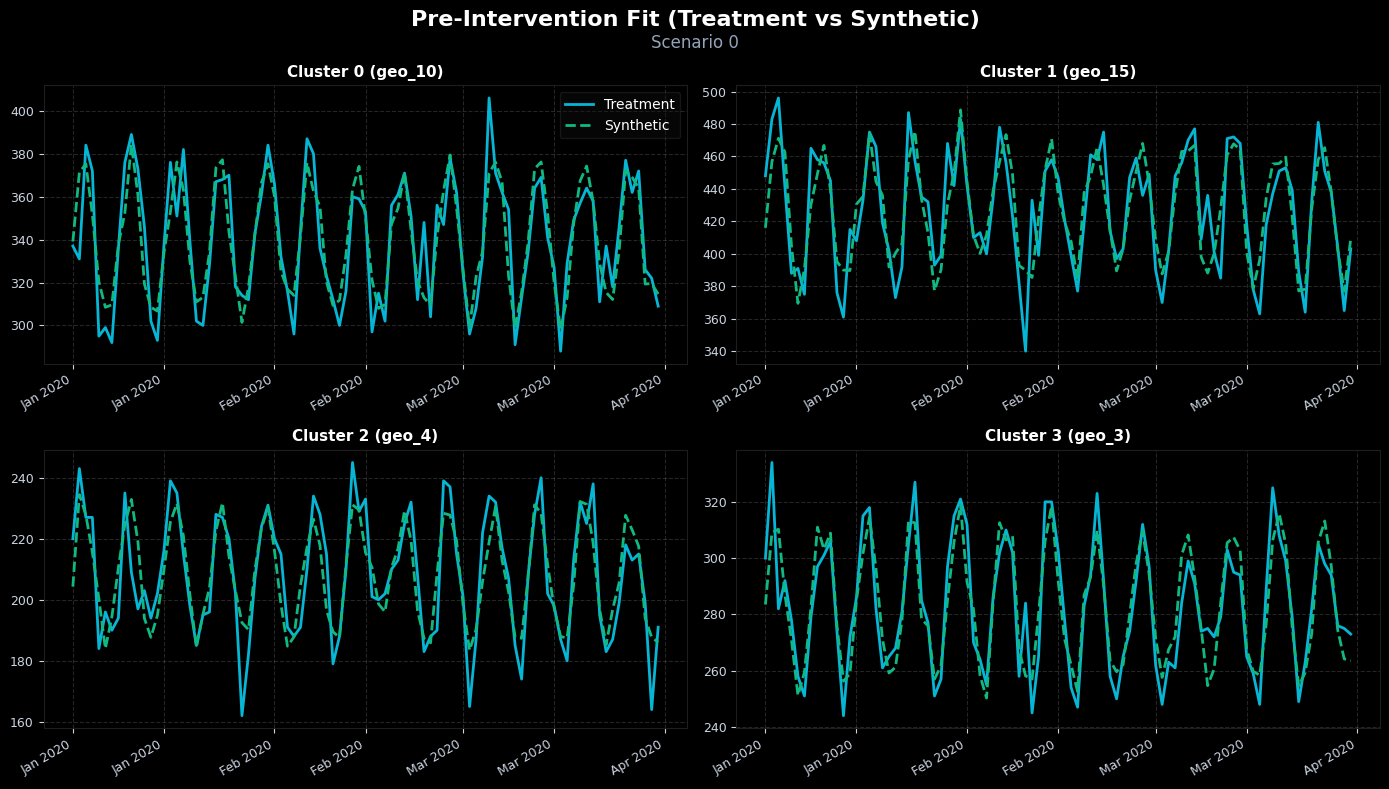

In [6]:
doe.plot_cluster_fits()

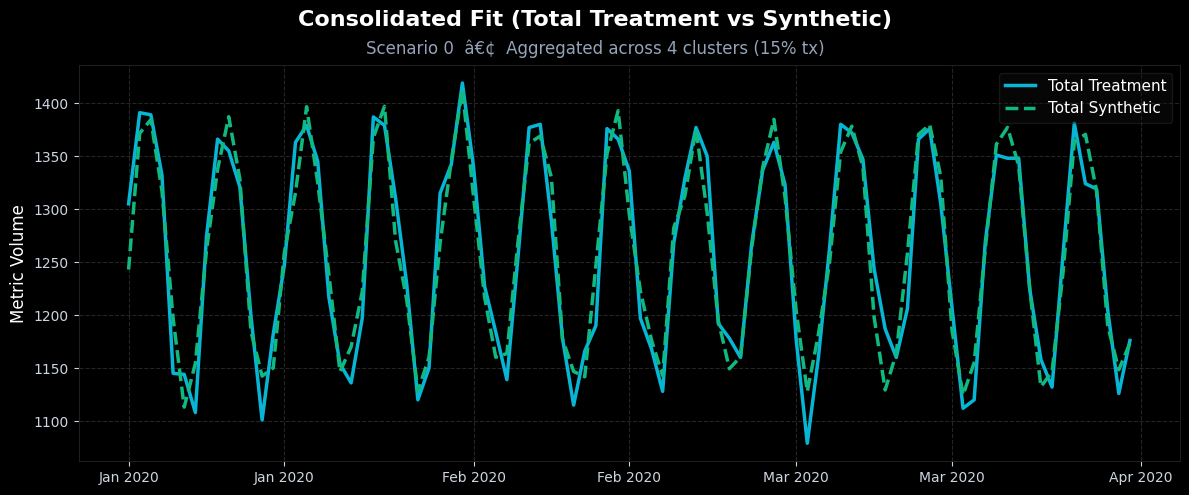

In [7]:
doe.plot_consolidated_fit()

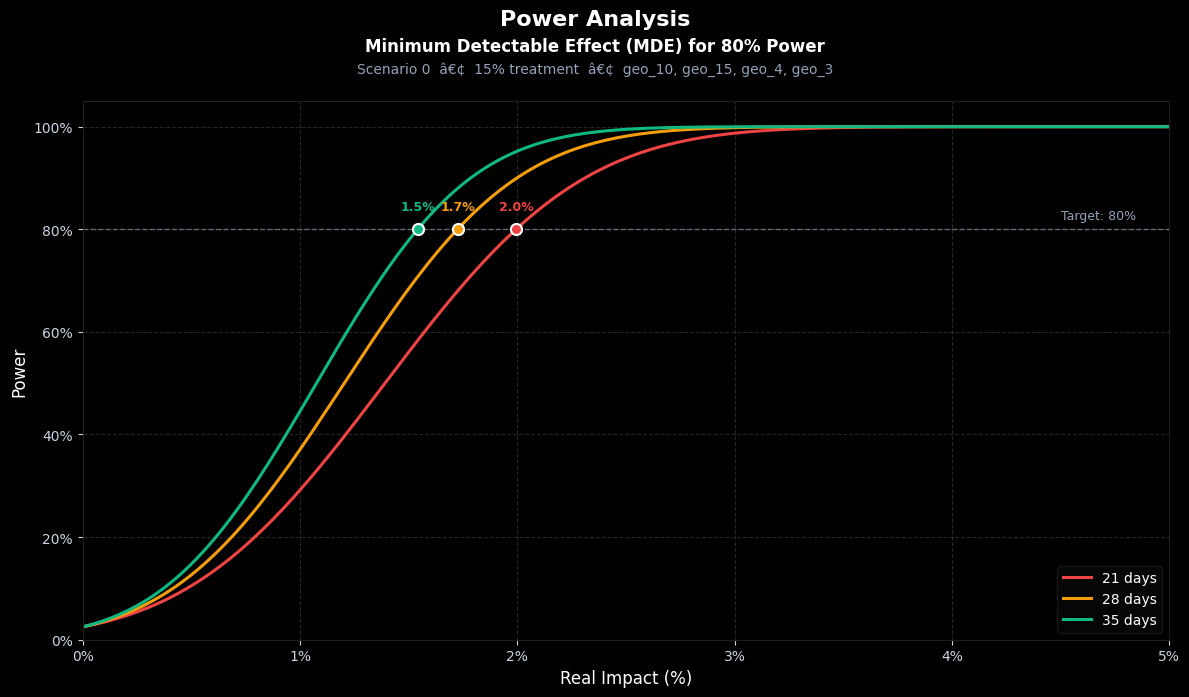

In [8]:
doe.plot_power_analysis()

## Step 5 — Backtest

Before running a real campaign, validate the design by injecting a **known lift of 0%** on the last
`days` of pre-test history. A well-designed experiment should return a non-significant result here —
confirming that the framework won't generate false positives on this data.

In [9]:
exp_results = rl.run(
    perform_backtesting={"lift": 0.0, "days": 28},
    doe=doe,
    scenario=0,
)


  BACKTESTING MODE
  Injected lift : +0.00%
  Window        : last 28 days of pre-test history
  Treatment geos: ['geo_10', 'geo_15', 'geo_4', 'geo_3']


>>> SIMULATION MODE: REAL HISTORY BACKTEST
>>> Intervention Period: 2020-03-04 00:00:00 to 2020-03-31 00:00:00 (28 days)

>>> Using experiment design from DoE Scenario 0

--------------------------------------------------
-------------- ANALYZING CLUSTER 0 ---------------
--------------------------------------------------
Treatment: ['geo_10']
Final Exclusive Controls: ['geo_0', 'geo_1', 'geo_5', 'geo_7', 'geo_11', 'geo_18', 'geo_24']


=== GEO SYNTHETIC CONTROL (Cluster 0) ===

Weights:
geo_0: 0.2521
geo_1: 0.0887
geo_5: 0.1455
geo_7: 0.1185
geo_11: 0.2835
geo_18: 0.0903
geo_24: 0.0215

Treatment period:
Start: 2020-03-04
End: 2020-03-31
Duration: 28 days

Mean lift (abs): 2.11
Mean lift (%): 0.70 %
Total lift: 59.20

=== SIGNIFICANCE (Cluster 0) ===

T-Test:
t-stat: 0.794
p-value: 0.4340

=== BOOTSTRAP TESTS SUMMARY (Cluster 0) ===

## Step 4 — Backtest

Before running a real campaign, validate the design by injecting a **known lift of 0%** on the last
`days` of pre-test history. A well-designed experiment should return a non-significant result here —
confirming that the framework won't generate false positives on this data.

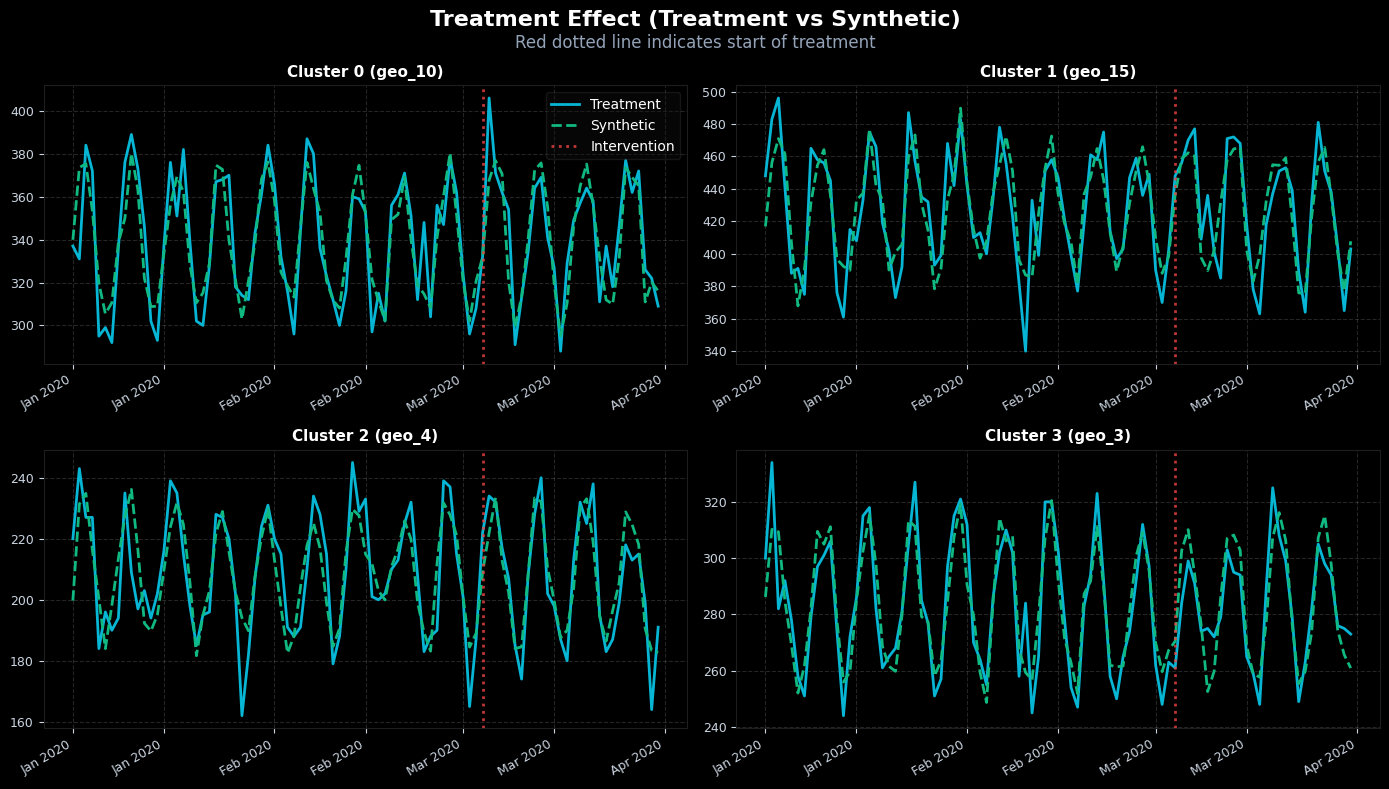

In [10]:
exp_results.plot_cluster_effects(post_only=False)

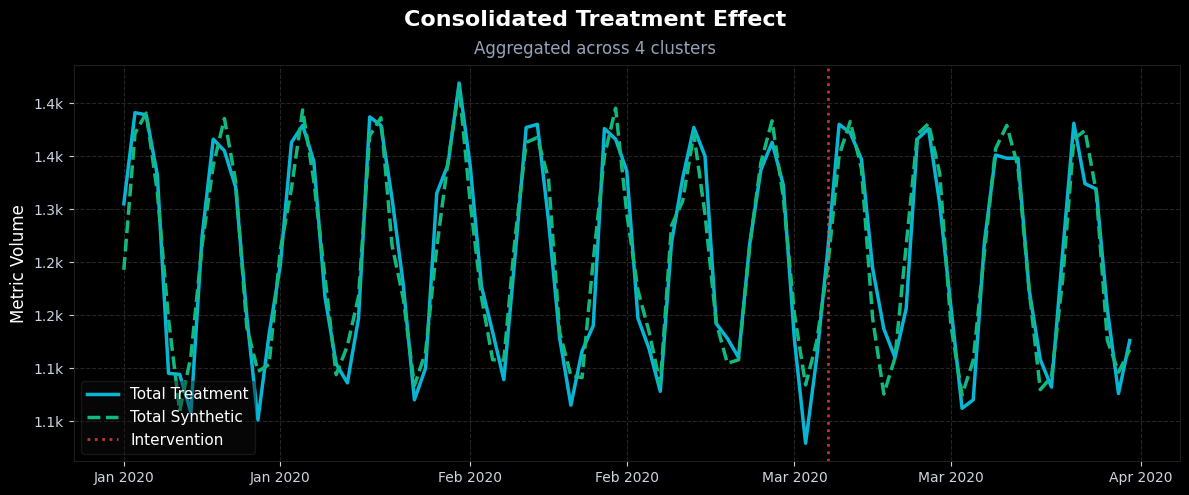

In [11]:
exp_results.plot_consolidated_effect(post_only=False)

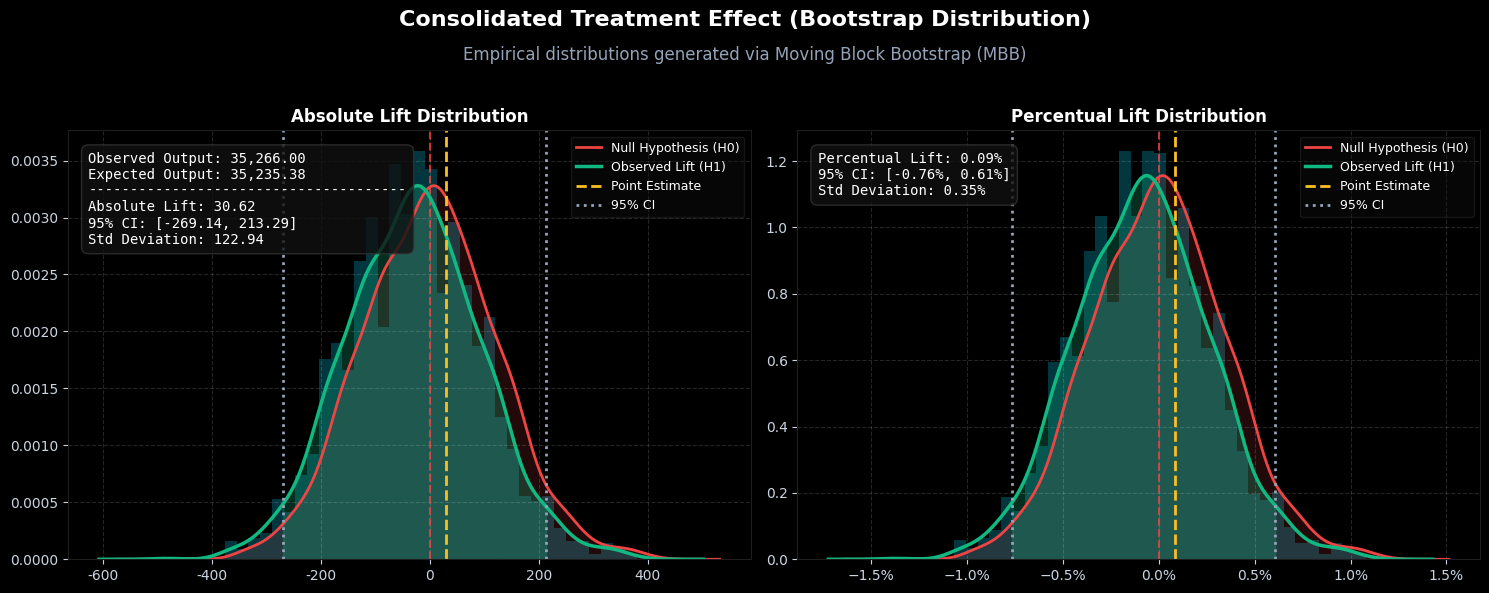

In [12]:
exp_results.plot_lift_distributions(show_null=True)